#Solving the Traveling Salesman Problem: A Comparative Analysis of Hill Climbing and Genetic Algorithm Optimisation

**Module:** UFCEL1-15-M — AI for Search and Optimisation
**Assessment:** Resit — Practical Skills Assessment (Portfolio)
**Student Name:** Keith Goatley
**Student Number:** 25043830

---

##Project Overview
This notebook implements and compares two approaches to solving the Traveling Salesman Problem (TSP) on a 50 city instance: a single-solution local search algorithm and a population-based Evolutionary Algorithm. Performance is evaluated across solution quality, convergence speed, computational efficiency, and scalability.

##Data Loading and Exploration

My first section loads the `cities.csv` file, which contains 50 cities defined by X and Y coordinates. Visualising the raw city layout provides context for interpreting the routes generated by each algorithm later in this notebook.

Number of cities loaded: 50


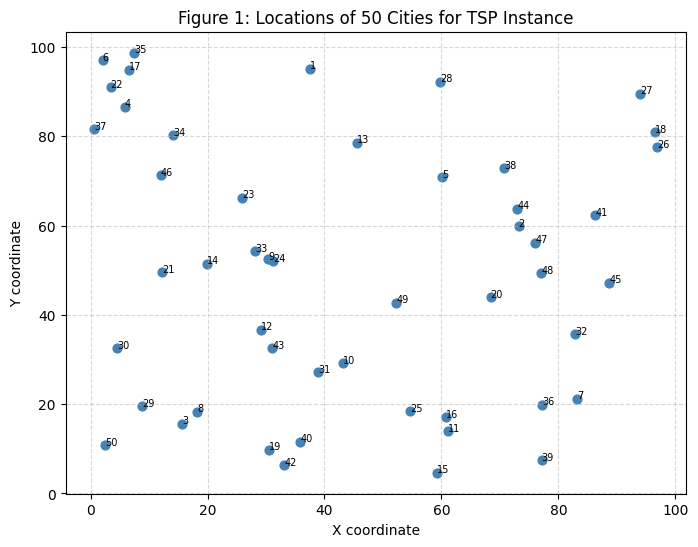

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def load_cities(filepath):
    """
    Load city coordinates from a CSV file into a DataFrame.

    Args:
        filepath (str): Path to the cities CSV file.

    Returns:
        pd.DataFrame: DataFrame with columns City, X, Y.
    """
    return pd.read_csv(filepath)

def plot_cities(df, title="City Locations"):
    """
    Plot city locations as a scatter plot.

    Args:
        df (pd.DataFrame): DataFrame containing X and Y coordinates.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(df['X'], df['Y'], c='steelblue', s=40)
    for _, row in df.iterrows():
        plt.annotate(row['City'].replace('City_', ''), (row['X'], row['Y']), fontsize=7)
    plt.title(title)
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

cities_df = load_cities('cities.csv')
print(f"Number of cities loaded: {len(cities_df)}")
plot_cities(cities_df, title="Figure 1: Locations of 50 Cities for TSP Instance")

##Distance Calculation

Both algorithms require a way to calculate the total distance of a route. This section will define a distance function between two cities and a function to compute the total tour distance, including the return to the starting city.

In [2]:
import numpy as np

def euclidean_distance(city1, city2):
    """
    Calculate Euclidean distance between two cities.

    Args:
        city1 (tuple): (x, y) coordinates of first city.
        city2 (tuple): (x, y) coordinates of second city.

    Returns:
        float: Euclidean distance between the two points.
    """
    return np.sqrt((city1[0] - city2[0])**2 + (city1[1] - city2[1])**2)

def total_distance(route, coords):
    """
    Calculate total distance of a tour, including return to start.

    Args:
        route (list): Ordered list of city indices representing the tour.
        coords (list): List of (x, y) tuples for each city, indexed to match route.

    Returns:
        float: Total distance of the closed tour.
    """
    dist = 0.0
    for i in range(len(route)):
        current_city = coords[route[i]]
        next_city = coords[route[(i + 1) % len(route)]]
        dist += euclidean_distance(current_city, next_city)
    return dist

coords = list(zip(cities_df['X'], cities_df['Y']))
sample_route = list(range(len(coords)))
print(f"Distance of unoptimised route (0,1,2,...,49): {total_distance(sample_route, coords):.2f}")

Distance of unoptimised route (0,1,2,...,49): 2663.96


##Hill Climbing (Random Forest)

The next cell uses a Random Restart Hill Climber, one of the three permitted single-solution search algorithms for Stage 1. I chose this because it addresses the main weakness of simple hill climbing by restarting from a new random solution when no improvement is found.

The neighbourhood structure uses a swap operator which is two randomly chosen cities in the route swap positions to generate a neighbour.

In [3]:
import random

def get_neighbour(route):
    """
    Generate a neighbouring solution by swapping two random cities.

    Args:
        route (list): Current route (list of city indices).

    Returns:
        list: New route with two cities swapped.
    """
    new_route = route.copy()
    i, j = random.sample(range(len(route)), 2)
    new_route[i], new_route[j] = new_route[j], new_route[i]
    return new_route

def hill_climb(coords, max_iterations=1000, stall_limit=100):
    """
    Random Restart Hill Climbing algorithm for TSP.

    Args:
        coords (list): List of (x, y) tuples for each city.
        max_iterations (int): Maximum total iterations across all restarts.
        stall_limit (int): Iterations without improvement before a random restart.

    Returns:
        tuple: (best_route, best_distance, history) where history logs
               best distance at each iteration for convergence plotting.
    """
    n = len(coords)
    current_route = list(range(n))
    random.shuffle(current_route)
    current_dist = total_distance(current_route, coords)

    best_route, best_dist = current_route, current_dist
    history = [best_dist]
    stall_counter = 0

    for _ in range(max_iterations):
        neighbour = get_neighbour(current_route)
        neighbour_dist = total_distance(neighbour, coords)

        if neighbour_dist < current_dist:
            current_route, current_dist = neighbour, neighbour_dist
            stall_counter = 0
        else:
            stall_counter += 1

        if current_dist < best_dist:
            best_route, best_dist = current_route, current_dist

        if stall_counter >= stall_limit:
            current_route = list(range(n))
            random.shuffle(current_route)
            current_dist = total_distance(current_route, coords)
            stall_counter = 0

        history.append(best_dist)

    return best_route, best_dist, history

best_route, best_dist, history = hill_climb(coords)
print(f"Best distance found by Hill Climbing: {best_dist:.2f}")

Best distance found by Hill Climbing: 1250.59


###Hill Climbing Results

The plots below should show: 1. the optimised route found by the Random Restart Hill Climber, and 2. the behaviour of the algorithm. The best distance improves across iterations including visible drops where random restarts occur.

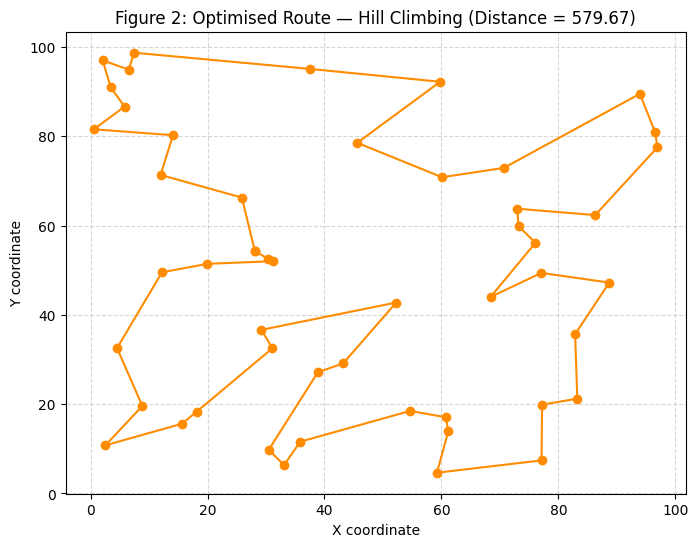

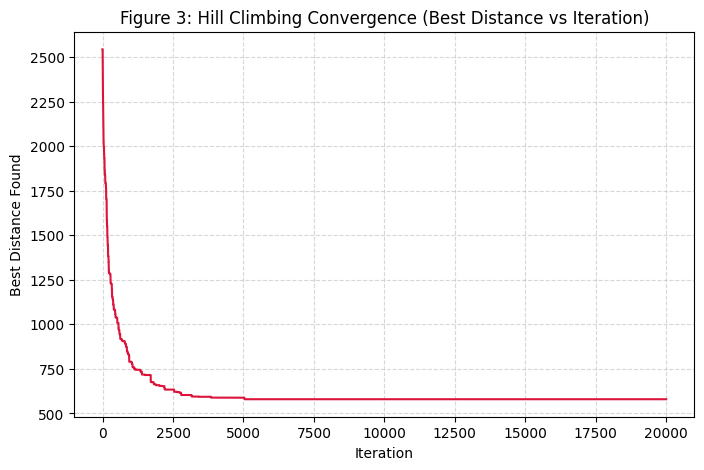

In [7]:
def plot_route(route, coords, title="Optimised Route"):
    """
    Plot a TSP route connecting cities in order, returning to start.

    Args:
        route (list): Ordered list of city indices.
        coords (list): List of (x, y) tuples for each city.
        title (str): Title for the plot.
    """
    ordered_coords = [coords[i] for i in route] + [coords[route[0]]]
    xs, ys = zip(*ordered_coords)
    plt.figure(figsize=(8, 6))
    plt.plot(xs, ys, 'o-', color='darkorange')
    plt.title(title)
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


plot_route(best_route, coords, title="Figure 2: Optimised Route — Hill Climbing (Distance = 579.67)")


plt.figure(figsize=(8, 5))
plt.plot(history, color='crimson')
plt.title("Figure 3: Hill Climbing Convergence (Best Distance vs Iteration)")
plt.xlabel("Iteration")
plt.ylabel("Best Distance Found")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

###Revised Hill Climbing with 2-opt Neighbourhood

The initial swap-based neighbourhood gave a route with multiple self-crossings, indicating a weak local search. I revised it to use a 2-opt move. Two edges in the route are selected and the segment between them is reversed. It directly removes crossing edges and produces a stronger, more exploitative search than simple swaps.

In [5]:
def two_opt_neighbour(route):
    """
    Generate a neighbouring solution using a 2-opt move.

    Selects two positions in the route and reverses the segment
    between them, which removes crossing edges.

    Args:
        route (list): Current route (list of city indices).

    Returns:
        list: New route with a segment reversed.
    """
    new_route = route.copy()
    i, j = sorted(random.sample(range(len(route)), 2))
    new_route[i:j+1] = reversed(new_route[i:j+1])
    return new_route

def hill_climb_2opt(coords, max_iterations=20000, stall_limit=2000):
    """
    Random Restart Hill Climbing with 2-opt neighbourhood for TSP.

    Args:
        coords (list): List of (x, y) tuples for each city.
        max_iterations (int): Maximum total iterations across all restarts.
        stall_limit (int): Iterations without improvement before a random restart.

    Returns:
        tuple: (best_route, best_distance, history)
    """
    n = len(coords)
    current_route = list(range(n))
    random.shuffle(current_route)
    current_dist = total_distance(current_route, coords)

    best_route, best_dist = current_route, current_dist
    history = [best_dist]
    stall_counter = 0

    for _ in range(max_iterations):
        neighbour = two_opt_neighbour(current_route)
        neighbour_dist = total_distance(neighbour, coords)

        if neighbour_dist < current_dist:
            current_route, current_dist = neighbour, neighbour_dist
            stall_counter = 0
        else:
            stall_counter += 1

        if current_dist < best_dist:
            best_route, best_dist = current_route, current_dist

        if stall_counter >= stall_limit:
            current_route = list(range(n))
            random.shuffle(current_route)
            current_dist = total_distance(current_route, coords)
            stall_counter = 0

        history.append(best_dist)

    return best_route, best_dist, history

best_route, best_dist, history = hill_climb_2opt(coords)
print(f"Best distance found by Hill Climbing (2-opt): {best_dist:.2f}")

Best distance found by Hill Climbing (2-opt): 579.67


###Saving the Best Route

The sequence of cities in the best route found by Hill Climbing is saved to an external file for record-keeping and reproducibility.

In [8]:
def save_route_to_file(route, cities_df, filename):
    """
    Save the sequence of cities in a route to a text file.

    Args:
        route (list): Ordered list of city indices.
        cities_df (pd.DataFrame): DataFrame containing city names.
        filename (str): Output filename.
    """
    with open(filename, 'w') as f:
        for idx in route:
            f.write(f"{cities_df.iloc[idx]['City']}\n")
        f.write(f"{cities_df.iloc[route[0]]['City']}\n")

save_route_to_file(best_route, cities_df, 'hill_climbing_best_route.txt')
print("Route saved to hill_climbing_best_route.txt")

with open('hill_climbing_best_route.txt') as f:
    print(f.read())

Route saved to hill_climbing_best_route.txt
City_33
City_23
City_46
City_34
City_37
City_4
City_22
City_6
City_17
City_35
City_1
City_28
City_13
City_5
City_38
City_27
City_18
City_26
City_41
City_44
City_2
City_47
City_20
City_48
City_45
City_32
City_7
City_36
City_39
City_15
City_11
City_16
City_25
City_40
City_42
City_19
City_31
City_10
City_49
City_12
City_43
City_8
City_3
City_50
City_29
City_30
City_21
City_14
City_24
City_9
City_33



##Genetic Algorithm (Evolutionary in this case)

This section uses a Genetic Algorithm (GA) to solve the same TSP instance, after the select-recombine-mutate-replace framework. The route is shown as a permutation of city indices. Order Crossover (OX) is used for recombination, as it preserves valid permutations, and swap mutation introduces diversity. Tournament selection is used to choose parents, biasing selection toward fitter individuals while retaining some randomness to preserve exploration.

In [9]:
def create_individual(n):
    """
    Create a random individual (route) as a permutation of city indices.

    Args:
        n (int): Number of cities.

    Returns:
        list: Random permutation of city indices.
    """
    individual = list(range(n))
    random.shuffle(individual)
    return individual

def create_population(pop_size, n):
    """
    Create an initial population of random individuals.

    Args:
        pop_size (int): Number of individuals in the population.
        n (int): Number of cities.

    Returns:
        list: List of individuals (routes).
    """
    return [create_individual(n) for _ in range(pop_size)]

def tournament_selection(population, fitnesses, k=5):
    """
    Select one parent using tournament selection.

    Args:
        population (list): List of individuals.
        fitnesses (list): Corresponding fitness (distance) values.
        k (int): Tournament size.

    Returns:
        list: Selected individual (route).
    """
    participants = random.sample(range(len(population)), k)
    best = min(participants, key=lambda idx: fitnesses[idx])
    return population[best]

pop_size = 100
population = create_population(pop_size, len(coords))
fitnesses = [total_distance(ind, coords) for ind in population]
print(f"Initial population size: {len(population)}")
print(f"Best fitness in initial random population: {min(fitnesses):.2f}")

Initial population size: 100
Best fitness in initial random population: 2219.97


###Crossover, Mutation, and Evolution Loop

Order Crossover (OX) uses two parent routes. Swap mutation randomly exchanges two cities in an individual with a small probability, introducing diversity to avoid premature convergence. The population changes over a fixed number of generations using elitism combined with tournament-selected offspring.

In [10]:
def order_crossover(parent1, parent2):
    """
    Perform Order Crossover (OX) between two parent routes.

    Args:
        parent1 (list): First parent route.
        parent2 (list): Second parent route.

    Returns:
        list: Child route produced by combining both parents.
    """
    size = len(parent1)
    start, end = sorted(random.sample(range(size), 2))
    child = [None] * size
    child[start:end] = parent1[start:end]

    fill_values = [gene for gene in parent2 if gene not in child]
    fill_positions = [i for i in range(size) if child[i] is None]

    for pos, val in zip(fill_positions, fill_values):
        child[pos] = val

    return child

def swap_mutation(individual, mutation_rate=0.02):
    """
    Apply swap mutation to an individual with a given probability per gene.

    Args:
        individual (list): Route to mutate.
        mutation_rate (float): Probability of mutation per city.

    Returns:
        list: Mutated route.
    """
    individual = individual.copy()
    for i in range(len(individual)):
        if random.random() < mutation_rate:
            j = random.randint(0, len(individual) - 1)
            individual[i], individual[j] = individual[j], individual[i]
    return individual

def genetic_algorithm(coords, pop_size=100, generations=500, mutation_rate=0.02, tournament_k=5):
    """
    Run a Genetic Algorithm to solve the TSP.

    Args:
        coords (list): List of (x, y) tuples for each city.
        pop_size (int): Population size.
        generations (int): Number of generations to evolve.
        mutation_rate (float): Probability of mutation per gene.
        tournament_k (int): Tournament selection size.

    Returns:
        tuple: (best_route, best_distance, history)
    """
    n = len(coords)
    population = create_population(pop_size, n)
    fitnesses = [total_distance(ind, coords) for ind in population]

    best_idx = fitnesses.index(min(fitnesses))
    best_individual = population[best_idx]
    best_fitness = fitnesses[best_idx]
    history = [best_fitness]

    for gen in range(generations):
        new_population = [best_individual]

        while len(new_population) < pop_size:
            parent1 = tournament_selection(population, fitnesses, tournament_k)
            parent2 = tournament_selection(population, fitnesses, tournament_k)
            child = order_crossover(parent1, parent2)
            child = swap_mutation(child, mutation_rate)
            new_population.append(child)

        population = new_population
        fitnesses = [total_distance(ind, coords) for ind in population]

        gen_best_idx = fitnesses.index(min(fitnesses))
        if fitnesses[gen_best_idx] < best_fitness:
            best_individual = population[gen_best_idx]
            best_fitness = fitnesses[gen_best_idx]

        history.append(best_fitness)

    return best_individual, best_fitness, history

ga_best_route, ga_best_dist, ga_history = genetic_algorithm(coords)
print(f"Best distance found by Genetic Algorithm: {ga_best_dist:.2f}")

Best distance found by Genetic Algorithm: 765.69


###Genetic Algorithm Results

The next plots should show the optimised route found by the Genetic Algorithm and its convergence over generations. Compared to Hill Climbing, the GA shows a smoother, more gradual convergence curve, reflecting population-level improvement rather than a single trajectory refinement.

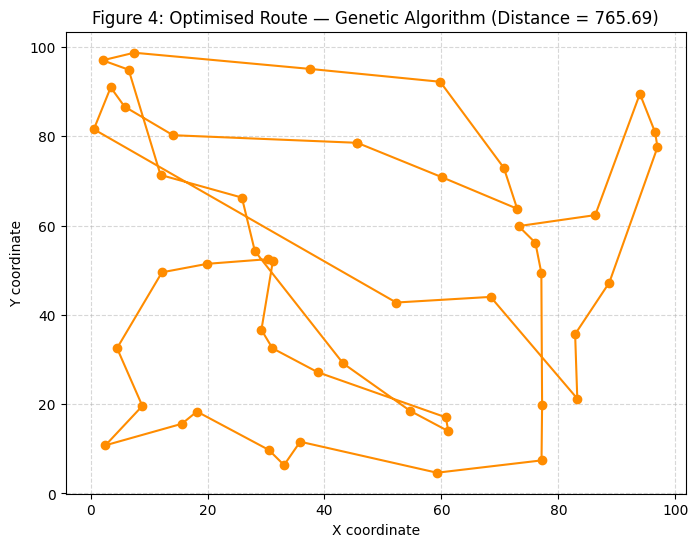

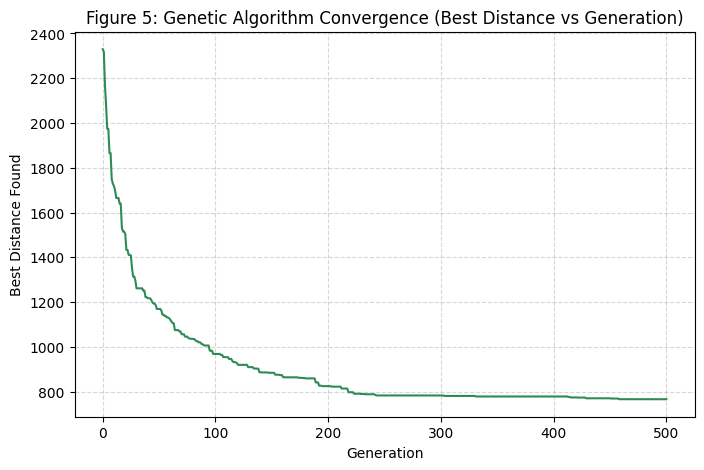

In [11]:
plot_route(ga_best_route, coords, title=f"Figure 4: Optimised Route — Genetic Algorithm (Distance = {ga_best_dist:.2f})")

plt.figure(figsize=(8, 5))
plt.plot(ga_history, color='seagreen')
plt.title("Figure 5: Genetic Algorithm Convergence (Best Distance vs Generation)")
plt.xlabel("Generation")
plt.ylabel("Best Distance Found")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

###Saving the GA Best Route

The best route found by the Genetic Algorithm is saved to an external file for record-keeping and reproducibility.

In [13]:
save_route_to_file(ga_best_route, cities_df, 'genetic_algorithm_best_route.txt')
print("Route saved to genetic_algorithm_best_route.txt")

with open('genetic_algorithm_best_route.txt') as f:
    print(f.read())

Route saved to genetic_algorithm_best_route.txt
City_13
City_5
City_44
City_38
City_28
City_1
City_35
City_6
City_17
City_46
City_23
City_33
City_10
City_25
City_11
City_16
City_31
City_43
City_12
City_24
City_9
City_14
City_21
City_30
City_29
City_50
City_3
City_8
City_19
City_42
City_40
City_15
City_39
City_36
City_48
City_47
City_2
City_41
City_27
City_18
City_26
City_45
City_32
City_7
City_20
City_49
City_37
City_22
City_4
City_34
City_13



##Scalability Testing

To look at how each algorithm scales, I'll run both Hill Climbing and the Genetic Algorithm on subsets of the city data at sizes 10, 20, 30, 40, and 50 cities. For each size, the best distance found and the computation time are recorded, enabling comparison of solution quality and efficiency as problem size increases.

In [14]:
import time

def run_scalability_test(cities_df, sizes):
    """
    Run Hill Climbing and Genetic Algorithm across varying problem sizes.

    Args:
        cities_df (pd.DataFrame): Full city dataset.
        sizes (list): List of problem sizes to test.

    Returns:
        pd.DataFrame: Results with columns for size, algorithm, distance, and time.
    """
    results = []

    for size in sizes:
        subset = cities_df.iloc[:size]
        subset_coords = list(zip(subset['X'], subset['Y']))

        start = time.time()
        _, hc_dist, _ = hill_climb_2opt(subset_coords, max_iterations=20000, stall_limit=2000)
        hc_time = time.time() - start
        results.append({'Size': size, 'Algorithm': 'Hill Climbing', 'Distance': hc_dist, 'Time': hc_time})

        start = time.time()
        _, ga_dist, _ = genetic_algorithm(subset_coords, pop_size=100, generations=500)
        ga_time = time.time() - start
        results.append({'Size': size, 'Algorithm': 'Genetic Algorithm', 'Distance': ga_dist, 'Time': ga_time})

        print(f"Size {size}: HC={hc_dist:.2f} ({hc_time:.2f}s), GA={ga_dist:.2f} ({ga_time:.2f}s)")

    return pd.DataFrame(results)

scalability_results = run_scalability_test(cities_df, [10, 20, 30, 40, 50])
scalability_results.to_csv('scalability_results.csv', index=False)
print("\nSaved to scalability_results.csv")

Size 10: HC=290.31 (0.38s), GA=290.31 (1.58s)
Size 20: HC=386.43 (0.73s), GA=386.63 (3.76s)
Size 30: HC=453.90 (0.94s), GA=501.81 (3.61s)
Size 40: HC=489.73 (1.20s), GA=590.65 (6.26s)
Size 50: HC=569.93 (1.67s), GA=665.36 (6.06s)

Saved to scalability_results.csv


##Scalability Results Visualisation

The charts below should compare distance and time between Hill Climbing and the Genetic Algorithm across problem sizes of 10, 20, 30, 40, and 50 cities. This shows how each algorithm scales as the number of cities increases.

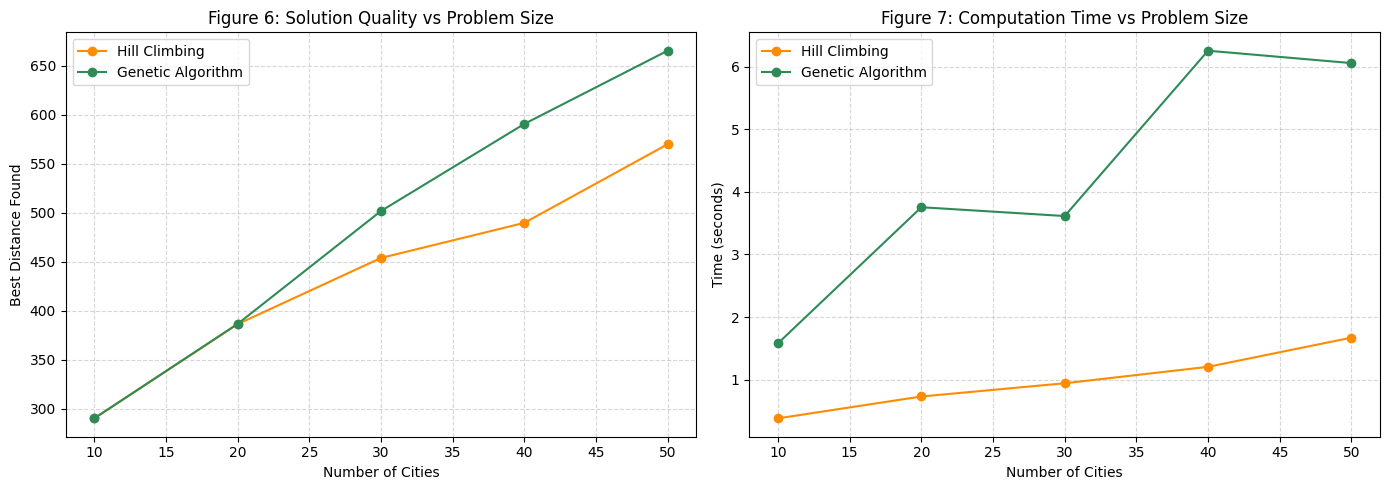

In [15]:
hc_data = scalability_results[scalability_results['Algorithm'] == 'Hill Climbing']
ga_data = scalability_results[scalability_results['Algorithm'] == 'Genetic Algorithm']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hc_data['Size'], hc_data['Distance'], 'o-', color='darkorange', label='Hill Climbing')
axes[0].plot(ga_data['Size'], ga_data['Distance'], 'o-', color='seagreen', label='Genetic Algorithm')
axes[0].set_title("Figure 6: Solution Quality vs Problem Size")
axes[0].set_xlabel("Number of Cities")
axes[0].set_ylabel("Best Distance Found")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(hc_data['Size'], hc_data['Time'], 'o-', color='darkorange', label='Hill Climbing')
axes[1].plot(ga_data['Size'], ga_data['Time'], 'o-', color='seagreen', label='Genetic Algorithm')
axes[1].set_title("Figure 7: Computation Time vs Problem Size")
axes[1].set_xlabel("Number of Cities")
axes[1].set_ylabel("Time (seconds)")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('scalability_comparison.png', dpi=150)
plt.show()

###Statistical Significance Testing

To prove that Hill Climbing outperforms the Genetic Algorithm on this problem, I've run both algorithms 10 times independently on the full 50-city instance. Then I used a paired t-test to determine whether the difference in mean solution quality is statistically significant, rather than due to random variation.

In [16]:
from scipy import stats

def repeated_runs(algorithm_func, coords, n_runs=10, **kwargs):
    """
    Run an algorithm multiple times and collect the best distances.

    Args:
        algorithm_func (callable): The algorithm function to run.
        coords (list): List of (x, y) tuples for each city.
        n_runs (int): Number of independent runs.
        **kwargs: Additional arguments passed to the algorithm function.

    Returns:
        list: List of best distances from each run.
    """
    distances = []
    for _ in range(n_runs):
        _, dist, _ = algorithm_func(coords, **kwargs)
        distances.append(dist)
    return distances

hc_runs = repeated_runs(hill_climb_2opt, coords, n_runs=10, max_iterations=20000, stall_limit=2000)
ga_runs = repeated_runs(genetic_algorithm, coords, n_runs=10, pop_size=100, generations=500)

print(f"Hill Climbing runs: {[f'{d:.2f}' for d in hc_runs]}")
print(f"Mean HC: {np.mean(hc_runs):.2f}, Std HC: {np.std(hc_runs):.2f}")
print(f"\nGenetic Algorithm runs: {[f'{d:.2f}' for d in ga_runs]}")
print(f"Mean GA: {np.mean(ga_runs):.2f}, Std GA: {np.std(ga_runs):.2f}")

t_stat, p_value = stats.ttest_rel(hc_runs, ga_runs)
print(f"\nPaired t-test: t-statistic = {t_stat:.4f}, p-value = {p_value:.6f}")

if p_value < 0.05:
    print("Result: statistically significant difference between algorithms (p < 0.05)")
else:
    print("Result: no statistically significant difference (p >= 0.05)")

Hill Climbing runs: ['593.31', '596.58', '570.77', '579.90', '589.25', '575.56', '580.42', '584.45', '588.86', '615.25']
Mean HC: 587.43, Std HC: 11.96

Genetic Algorithm runs: ['660.02', '617.19', '705.18', '685.44', '716.25', '711.95', '652.82', '768.73', '680.21', '690.70']
Mean GA: 688.85, Std GA: 39.10

Paired t-test: t-statistic = -6.9433, p-value = 0.000067
Result: statistically significant difference between algorithms (p < 0.05)
